In [ ]:
%pip install matplotlib

In [ ]:
import subprocess
import os
import matplotlib.pyplot as plt

def sh(command):
    res = subprocess.run(["bash", "-c", command], 
                       capture_output=True, 
                       text=True)
    if res.returncode != 0:
        print(f"Error executing command: {command}")
        print(f"Return code: {res.returncode}")
        print(f"stderr: {res.stderr}")
        raise Exception("Command failed")
    
    return res.stdout

The Code in this file should be used to scrape and set up the training data, compile relevant CLIs and so forth.

In [30]:
# Install CLI Tools required later.
sh("cd chord-simplify && ./install.sh")
sh("cd frequency-analysis && ./install.sh")


''

This next one can really take a while.

In [ ]:
# Scrape chordsheets from Ultimate-Guitar
subprocess.run(["bash", "-c", "cd ug-scrape && node main.js"])

In [ ]:
# Let's simplify the whitespace in all the files we just scraped.
sh("""
    for f in ug-scrape/output/*; do
        ./simplify-whitespace "$f" &
    done
   """)

## Generating Set of Raw tokens

We do not generate the final list of tokens immediately.
This is because the amount of final tokens is immense, and also some outliers are still present.

We use the set of raw tokens for further analysis down the line.

In [ ]:
# Create directory for first stage of token extraction
os.mkdir("output")

In [ ]:
subprocess.run(["bash", "-c", """
    npx tsx token-extract/main.ts ug-scrape/output ./config/almost-all-valid-tokens.csv > output/raw-tokens
"""])

In [ ]:
# you probably wont need this, here I'm using other data local to my machine.

subprocess.run(["bash", "-c", """
    cd token-extract
    npx tsx main.js :default ../config/almost-all-valid-tokens.csv  >> ../output/raw-tokens
"""])

In [23]:
# This step is about analysing the distribution of our tokens / training data and refining the actual set of tokens we use for our model.

rawTokenAnalysis = sh("frequency-analysis --no-header < output/raw-tokens")
print(rawTokenAnalysis)
chordFrequency = list()
chordToken = list()
for line in rawTokenAnalysis.splitlines():
    freq, token = line.split(";")
    chordFrequency.append(int(freq))
    chordToken.append(token)

153220;g
122675;c
106246;d
72697;a
69293;f
67397;am
59730;em
50923;e
29538;bm
27207;dm
22799;b
17508;bb
16335;f#m
12473;<start-of-song>
10856;c#m
10243;f#
9548;gm
8622;em7
8183;eb
7712;am7
6756;cm
6498;cadd9
6207;ab
5679;g#m
5403;d/f#
5061;e7
4985;a7
4975;fm
4660;d7
4621;dm7
4592;b7
4551;fmaj7
4371;c#
4162;cmaj7
4053;g/b
4027;bm7
3878;g7
3537;db
3374;g#
2634;bbm
2544;dsus4
2411;c7
2329;dsus2
2269;gmaj7
2155;asus2
2008;gm7
1964;f#m7
1958;g5
1891;a#
1886;dmaj7
1870;d#m
1689;c/g
1650;e5
1616;gb
1612;c#m7
1605;d#
1598;a5
1587;asus4
1570;c/e
1547;d5
1419;c5
1274;b5
1218;cm7
1196;ebm
1175;g6
1125;fm7
1088;a/c#
1041;amaj7
1038;c/b
1032;f5
1023;f7
994;gsus4
987;a#m
961;f#7
903;e/g#
889;emaj7
741;esus4
735;ebmaj7
728;d/a
726;bbmaj7
666;abm
650;g/d
624;g/f#
624;g#m7
606;bmaj7
594;f/a
587;f#5
576;c#7
532;bbm7
493;bb5
488;c#5
478;f/c
477;c9
463;bb7
445;a7sus4
426;csus2
413;bsus4
393;aadd9
384;fadd9
382;gsus2
381;d6
372;fsus2
371;ebm7
366;dsus
341;d9
341;am/g
336;gadd9
335;asus
334;g#7
330;em9
321;

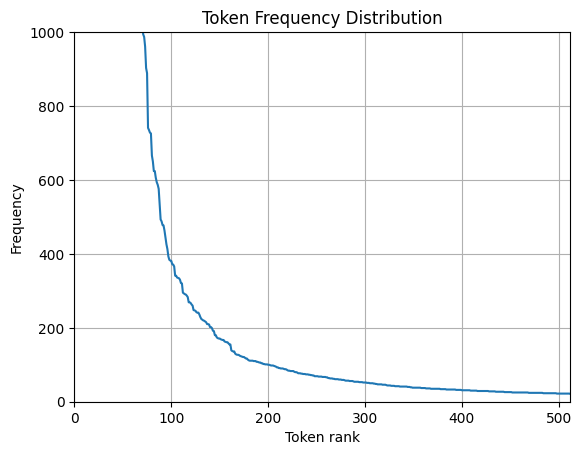

In [22]:

# We're drawing a graph of chordFrequency to help decide a cutoff point.
fig, ax = plt.subplots()
ax.plot(chordFrequency)
ax.set_ylim(top=1000, bottom=0)
ax.set_xlim(left=0, right=512)
ax.set_ylabel('Frequency')
ax.set_xlabel('Token rank')
ax.set_title('Token Frequency Distribution')
ax.grid(True)
#fig.savefig('token_frequency_distribution.png')
plt.show()

In [ ]:
# This variable is critical for our LLM infrastructure. 
# It defines the size of the vocabulary we will use and as such impacts the Models architecture.
# This number was chosen based on the output of our frequency analysis; 
# after rank 200 we reach barely a hundred occurencec per token, at 265 it's almost half that. Further down the line I suspect it's too little to work with.
# At the same time, we still cover plenty of interesting chords and by far all "standard" chords this way.
VOCABULARY_SIZE = 256

validChords = chordToken[:VOCABULARY_SIZE]
# write validChords to file
with open("config/valid-tokens.csv", "w") as f:
    for chord in validChords:
        f.write(f"{chord}\n")

print(validChords)

['g', 'c', 'd', 'a', 'f', 'am', 'em', 'e', 'bm', 'dm', 'b', 'bb', 'f#m', '<start-of-song>', 'c#m', 'f#', 'gm', 'em7', 'eb', 'am7', 'cm', 'cadd9', 'ab', 'g#m', 'd/f#', 'e7', 'a7', 'fm', 'd7', 'dm7', 'b7', 'fmaj7', 'c#', 'cmaj7', 'g/b', 'bm7', 'g7', 'db', 'g#', 'bbm', 'dsus4', 'c7', 'dsus2', 'gmaj7', 'asus2', 'gm7', 'f#m7', 'g5', 'a#', 'dmaj7', 'd#m', 'c/g', 'e5', 'gb', 'c#m7', 'd#', 'a5', 'asus4', 'c/e', 'd5', 'c5', 'b5', 'cm7', 'ebm', 'g6', 'fm7', 'a/c#', 'amaj7', 'c/b', 'f5', 'f7', 'gsus4', 'a#m', 'f#7', 'e/g#', 'emaj7', 'esus4', 'ebmaj7', 'd/a', 'bbmaj7', 'abm', 'g/d', 'g/f#', 'g#m7', 'bmaj7', 'f/a', 'f#5', 'c#7', 'bbm7', 'bb5', 'c#5', 'f/c', 'c9', 'bb7', 'a7sus4', 'csus2', 'bsus4', 'aadd9', 'fadd9', 'gsus2', 'd6', 'fsus2', 'ebm7', 'dsus', 'd9', 'am/g', 'gadd9', 'asus', 'g#7', 'em9', 'abmaj7', 'c/d', 'eb5', 'd#m7', 'd/e', 'c2', 'csus4', 'ab7', 'gadd11', 'bb/d', 'f6', 'b/d#', 'g#5', 'am/e', 'a6', 'a/e', 'bsus2', 'eb7', 'd/c', 'a2', 'g/a', 'dbmaj7', 'd7sus4', 'em/b', 'dadd9', 'dbm', 'f

# Next step is to generate the final input data.

We take the total amount of tokens generated and 
    - 1.) try to simplify chords to fit our target set of valid chords (e.g. Emaj7 => E7)  
    - 2.) Remove any tokens that don't fit this pattern, as we still have some undected noise here.
  
After this step there is no filtering out of the noise feasable anymore

In [ ]:
sh("chord-simplify config/valid-tokens.csv < output/raw-tokens > output/tokens")
# you can open the files in a diff viewer to see the difference.
print("final input data for llm training now lives in output/tokens")

360c360
< g#sus4
---
> g#
378c378
< g#sus4
---
> g#
384c384
< g#sus4
---
> g#
390c390
< g#sus4
---
> g#
396c396
< g#sus4
---
> g#



In [ ]:
# here we define our mapper functions to go from token to number and back again.
def tokenToNumber(token: str) -> int:
    return validChords.index(token)

def numberToToken(number: int) -> str:
    return validChords[number]